# Deep Learning Practical Report 2(ANN Adult census income)

## Task 1: Data Loading, Cleaning & Exploratory Data Analysis

### 1.1 Load and inspect the dataset

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("adult.csv")
print(df.shape)
print(df.dtypes)
display(df.head())


(48842, 15)
age                 int64
workclass          object
fnlwgt              int64
education          object
educational-num     int64
marital-status     object
occupation         object
relationship       object
race               object
gender             object
capital-gain        int64
capital-loss        int64
hours-per-week      int64
native-country     object
income             object
dtype: object


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [15]:
for col in df.select_dtypes('object'):
    df[col] = df[col].str.strip()

### 1.2 Handle missing values

In [16]:
# missing values have ? so I replace with NAN

df.replace('?',np.nan,inplace=True)
print(df.isnull().sum())

df.dropna(inplace=True)
print(df.shape)

# I dropped the missing rows because all the columns with missing values were categorical values with many categories and imputing them with 
# mode will disrupt the balanced and true nature of dataset and also the missing values were a small fraction of dataset so removing it was much safer. 

age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64
(45222, 15)


### 1.3 Drop redundant columns

In [17]:
# fnlwgt will be dropped because its not a real feature and doesnt have a significance of a adult. 
# education will be dropped because education-num shows the same thing numerically.

df.drop(columns=['fnlwgt','education'],inplace=True)
print(df.shape)

(45222, 13)


### 1.4 Encode the target

income
0    34014
1    11208
Name: count, dtype: int64


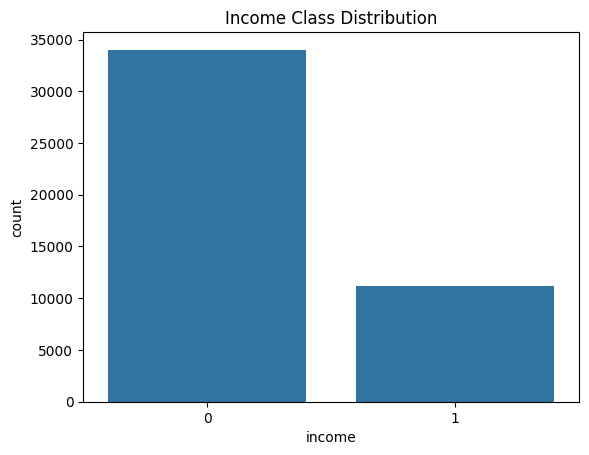

In [18]:
#  0 (<=50K) and 1 (>50K)
df['income'] = (df['income'] == '>50K').astype(int)
print(df['income'].value_counts())

sns.countplot(x='income', data=df)
plt.title('Income Class Distribution')
plt.savefig("Income Class Distribution",dpi=300)
plt.show()

# We will track F1-score, Precision, and Recall alongside accuracy throughout.


### 1.5 Exploratory visualisations

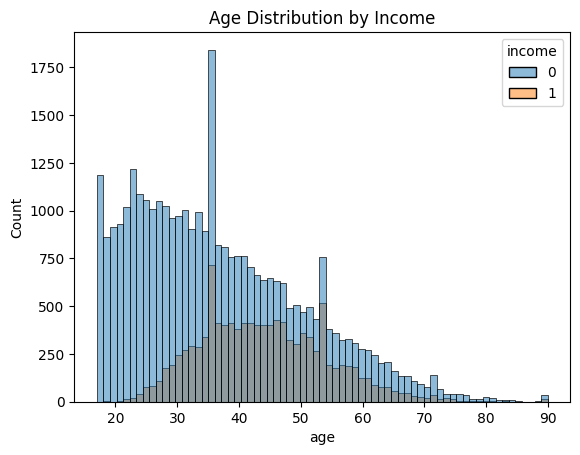

In [ ]:
sns.histplot(data=df, x='age', hue='income')
plt.title('Age Distribution by Income')
plt.savefig('Age Distribution by Income',dpi=300)
plt.show()

# Older individuals (roughly 35-55) are more likely to earn >50K, while the <=50K group skews younger.

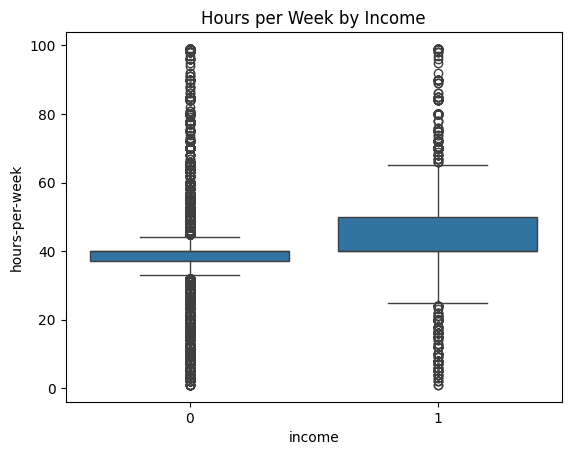

In [ ]:
sns.boxplot(data=df, x='income', y='hours-per-week')
plt.title('Hours per Week by Income')
plt.savefig('Hours per Week by Income',dpi=300)
plt.show()

# People earning >50K tend to work more hours per week, with a higher median and less spread than the <=50K group.

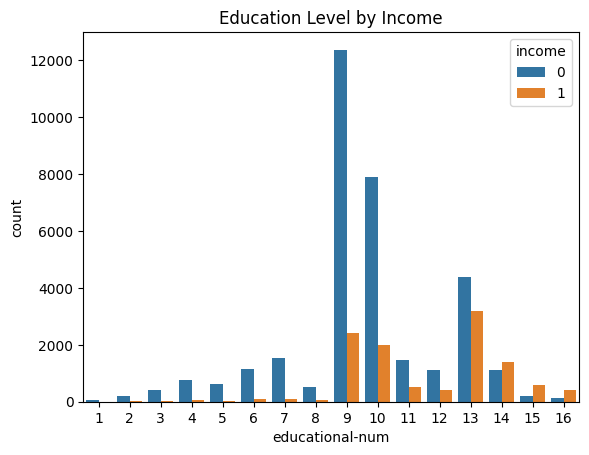

In [ ]:
sns.countplot(data=df, x='educational-num', hue='income')
plt.title('Education Level by Income')
plt.savefig('Education Level by Income',dpi=300)
plt.show()

# Higher education levels are associated with a much higher share of >50K earners, showing education is a strong individual predictor of income.

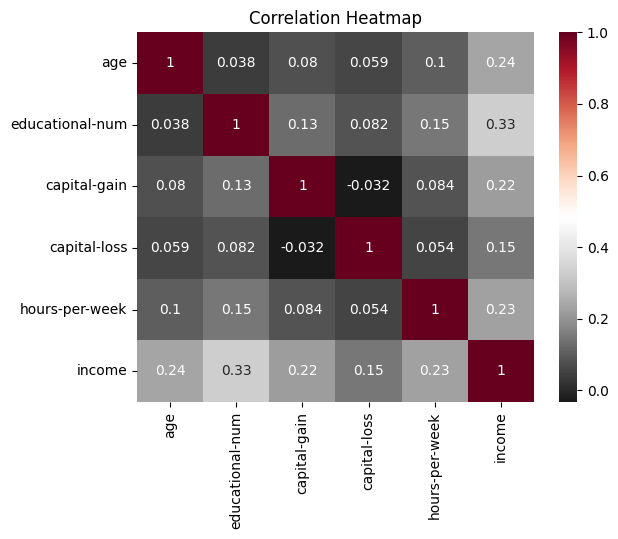

In [ ]:
num_cols = ['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'income']
sns.heatmap(df[num_cols].corr(), annot=True, cmap='RdGy_r')
plt.title('Correlation Heatmap')
plt.savefig('Correlation Heatmap',dpi=300)
plt.show()

# educational-num and hours-per-week show the strongest positive correlation with income among
# numeric features, followed by age. No two numeric features are strongly collinear with each other.

### 1.6 Encode categoricals & scale numerics

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('income', axis=1)
y = df['income']
X = pd.get_dummies(X, drop_first=True) # converts categorical col into new numerical cols and drops first new num col as one col is enough for understanding. 
print(X.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

num_features = ['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
scaler = StandardScaler()
X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(45222, 80)
(36177, 80) (9045, 80)
income
0    0.752163
1    0.247837
Name: proportion, dtype: float64
income
0    0.752128
1    0.247872
Name: proportion, dtype: float64


## Task 2: MLP Architecture — Baseline ANN

### 2.1 Define the reusable build_ann() function

In [27]:
import tensorflow as tf
from tensorflow import keras

def build_ann(input_dim, hidden_units=[128, 64], activation='relu',
              initializer='glorot_uniform', use_batch_norm=False,
              optimizer='adam', loss='binary_crossentropy'):
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(input_dim,)))
    for units in hidden_units:
        model.add(keras.layers.Dense(units, kernel_initializer=initializer))
        if use_batch_norm:
            model.add(keras.layers.BatchNormalization())
        model.add(keras.layers.Activation(activation))
    model.add(keras.layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])
    return model

### 2.2 Baseline ANN architecture

In [28]:
model_base = build_ann(input_dim=X_train.shape[1])
model_base.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,689 (73.00 KB)

 Trainable params: 18,689 (73.00 KB)

 Non-trainable params: 0 (0.00 B)

### 2.3 Train the baseline

Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8421 - loss: 0.3374 - val_accuracy: 0.8516 - val_loss: 0.3255
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 974us/step - accuracy: 0.8526 - loss: 0.3145 - val_accuracy: 0.8557 - val_loss: 0.3190
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 955us/step - accuracy: 0.8555 - loss: 0.3107 - val_accuracy: 0.8505 - val_loss: 0.3198
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8567 - loss: 0.3081 - val_accuracy: 0.8535 - val_loss: 0.3213
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 964us/step - accuracy: 0.8587 - loss: 0.3058 - val_accuracy: 0.8538 - val_loss: 0.3202
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 974us/step - accuracy: 0.8585 - loss: 0.3036 - val_accuracy: 0.8494 - val_loss: 0.3228
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 976us/step - accuracy: 0.8594 - loss: 0.3010 - val_accuracy: 0.8538 - val_loss: 0.3198
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 955us/step - accuracy: 0.8610 - loss: 0.2986 - val_

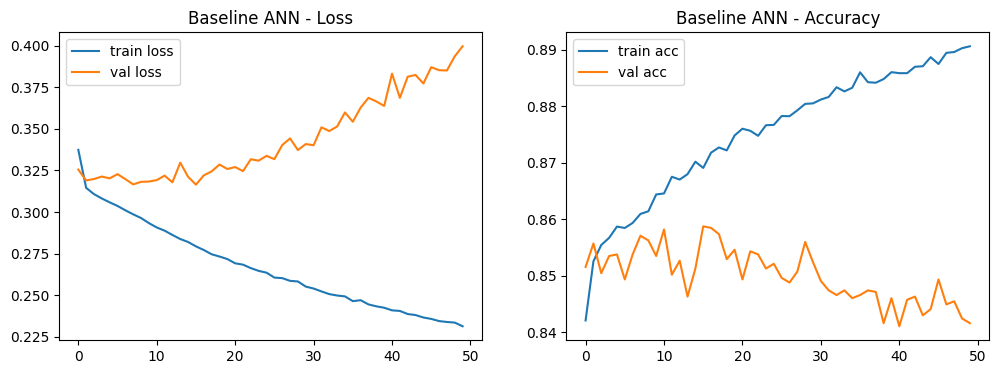

In [29]:
# Training for 50 epochs, holding out 10% of the training data for validation, then plotting the loss and accuracy curves.

history_base = model_base.fit(X_train, y_train, epochs=50, batch_size=64,
                               validation_split=0.1, verbose=1)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_base.history['loss'], label='train loss')
plt.plot(history_base.history['val_loss'], label='val loss')
plt.title('Baseline ANN - Loss')
plt.legend()
plt.savefig('Baseline ANN - Loss',dpi=300)

plt.subplot(1,2,2)
plt.plot(history_base.history['accuracy'], label='train acc')
plt.plot(history_base.history['val_accuracy'], label='val acc')
plt.title('Baseline ANN - Accuracy')
plt.legend()
plt.savefig('Baseline ANN - Accuracy',dpi=300)

plt.show()

### 2.4 Evaluate the baseline with full metrics

283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 446us/step
              precision    recall  f1-score   support

           0       0.89      0.90      0.89      6803
           1       0.68      0.67      0.68      2242

    accuracy                           0.84      9045
   macro avg       0.79      0.78      0.78      9045
weighted avg       0.84      0.84      0.84      9045



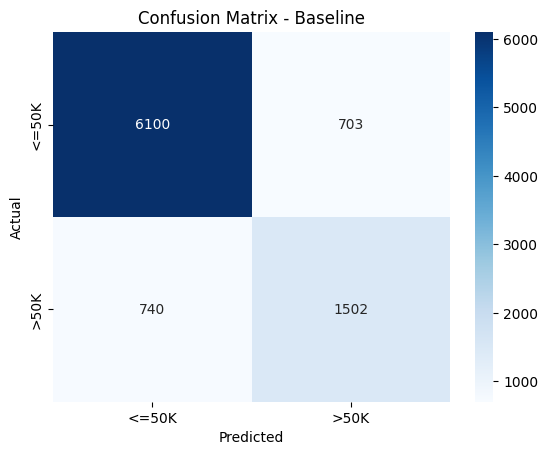

In [31]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_prob = model_base.predict(X_test).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['<=50K','>50K'], yticklabels=['<=50K','>50K'])
plt.title('Confusion Matrix - Baseline')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('Confusion Matrix - Baseline',dpi=300)
plt.show()

#### 6100 (True Negatives): correctly predicted <=50K
#### 703 (False Positives): actually <=50K, but model predicted >50K
#### 740 (False Negatives): actually >50K, but model predicted <=50K — these are the "high earners" your model missed
#### 1502 (True Positives): correctly predicted >50K

### 2.5 Why tabular data suits ANN
Tabular data like this (numeric + one-hot encoded categorical features) is the natural input for a
fully connected MLP, unlike image data (which needs CNNs) or sequence data (which needs RNNs).
Each input neuron receives one scaled feature, and the hidden layers learn combinations between
features — like age combined with education level — that a simple logistic regression can't
capture on its own.